## Load Data

In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import gc
from pathlib import Path
import sys
PROJECT_ROOT = Path("/home/jovyan/work/MST")
sys.path.append(str(PROJECT_ROOT))

from mst_xai.evaluation_methods.perturbation_core_code.perturbation_core import perturbation_evaluation
from mst.data.datasets.dataset_3d_odelia import ODELIA_Dataset3D
from mst.inference.predictor import load_model
from mst_xai.utils.load_saliency import load_saliency





A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found

/home/jovyan/work/MST/mst/models/extern/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/jovyan/work/MST/mst/models/extern/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/jovyan/work/MST/mst/models/extern/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [2]:
import pickle
with open("uid_to_index.pkl", "rb") as f:
    uid_to_index = pickle.load(f)

In [3]:
ds = ODELIA_Dataset3D(
    path_root="/home/jovyan/work/MST/mst/data/datasets/ODELIA_datasets",
    split="test"
)

In [4]:
example_uid = "ODELIA_TRICKS_0067_1_left"
example_index = uid_to_index[example_uid]
print(f"Example UID: {example_uid}, Index: {example_index}")

Example UID: ODELIA_TRICKS_0067_1_left, Index: 1


In [5]:
run_dir = Path("/home/jovyan/work/MST/runs")

## For DINOv2
# run_folder = Path("DINOv2ViTS/DinoV2ClassifierSlice_Final")
# path_run = run_dir / run_folder

##For New Model
run_folder = Path("DINOv3ViTB")
checkpoint_name = "challenge_mstv3-vit_sch_CB_sub2_best.chkpt"
path_run = run_dir / run_folder / checkpoint_name

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = load_model("DinoV2ClassifierSlice", path_run, device)
model.to(device)
model.eval()

Using cache found in /home/jovyan/.cache/torch/hub/facebookresearch_dinov3_main


DinoV2ClassifierSlice(
  (loss_func): CrossEntropyLoss()
  (auc_roc): ModuleDict(
    (train_): MulticlassAUROC()
    (val_): MulticlassAUROC()
    (test_): MulticlassAUROC()
  )
  (acc): ModuleDict(
    (train_): MulticlassAccuracy()
    (val_): MulticlassAccuracy()
    (test_): MulticlassAccuracy()
  )
  (encoder): DinoVisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (rope_embed): RopePositionEmbedding()
    (blocks): ModuleList(
      (0-11): 12 x SelfAttentionBlock(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): SelfAttention(
          (qkv): LinearKMaskedBias(in_features=768, out_features=2304, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (norm2): Layer

In [6]:
sample = ds[example_index]
gt = sample["target"]
batch = {
    "source": sample["source"].unsqueeze(0).to(device),
    "target": torch.tensor([gt], device=device)
}

In [7]:
with torch.no_grad():
    logits = model(batch["source"])
    probs = torch.softmax(logits, dim=-1)

pred_class = probs.argmax(dim=1).item()

print("Predicted class:", pred_class)

Predicted class: 2


In [8]:
saliency_map = "gradcam"
label = "2"
uid = example_uid
# Example: Grad-CAM / Attention rollout etc.
saliency_path = (
    f"/home/jovyan/work/MST/results/DINOv3ViTB/saliency_results/"
    f"{saliency_map}/class_{label}/pt/{uid}_importance.pt"
)

sal = torch.load(saliency_path, map_location="cpu", weights_only=True)

In [9]:
def run_single_mode(mode):

    replacements = [
        "black-5",
        "minimum-intensity",
        "white-5",
        "gaussian_blur",
        "attention_mask"
    ]

    results = {}

    for rep in replacements:
        out = perturbation_evaluation(
            model=model,
            batch=batch,
            saliency=sal,
            predicted_class=pred_class,
            patch_size=16,
            steps=20,
            mode=mode,
            replacement=rep,
            return_images=True,
            slice_index=10
        )

        results[rep] = {
            "images": out[5],
            "auc": out[4]
        }

        print(f"{mode} | {rep} | AUC: {out[4]:.4f}")

    return results

In [10]:
# def plot_mode(results, title):

#     steps = 20
#     step_ids = [0, 4, 8, 12, 16, 20]

#     reps = list(results.keys())

#     fig, axes = plt.subplots(len(reps), len(step_ids), figsize=(15, 10))

#     for i, rep in enumerate(reps):
#         imgs = results[rep]["images"]

#         for j, s in enumerate(step_ids):
#             ax = axes[i, j]
#             ax.imshow(imgs[s], cmap="gray", vmin=-3, vmax=3)
#             ax.axis("off")

#             if i == 0:
#                 ax.set_title(f"{int(s/20*100)}%")

#             if j == 0:
#                 ax.set_ylabel(rep)

#     plt.suptitle(title)
#     plt.tight_layout()
#     plt.show()

In [15]:
def plot_mode(results, title,source):

    steps = 20
    step_ids = [0, 4, 8, 12, 16, 20]

    reps = list(results.keys())

    fig, axes = plt.subplots(len(reps), len(step_ids), figsize=(15, 10))

    for i, rep in enumerate(reps):
        imgs = results[rep]["images"]

        for j, s in enumerate(step_ids):
            ax = axes[i, j]
            vmin = source.min().item()
            vmax = source.max().item()

            ax.imshow(imgs[s], cmap="gray", vmin=vmin, vmax=vmax)
            ax.axis("off")

            # column titles (top row only)
            if i == 0:
                ax.set_title(f"{int(s/steps*100)}%", fontsize=11)

    # ✅ Proper Y-axis labels (centered per row)
    for i, rep in enumerate(reps):
        axes[i, 0].annotate(
            rep,
            xy=(-0.35, 0.5),  # move left of grid
            xycoords='axes fraction',
            va='center',
            ha='right',
            fontsize=12,
            rotation=0
        )

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

deletion | black-5 | AUC: 0.0812
deletion | minimum-intensity | AUC: 0.1217
deletion | white-5 | AUC: 0.3048
deletion | gaussian_blur | AUC: 0.4668
deletion | attention_mask | AUC: 0.1917


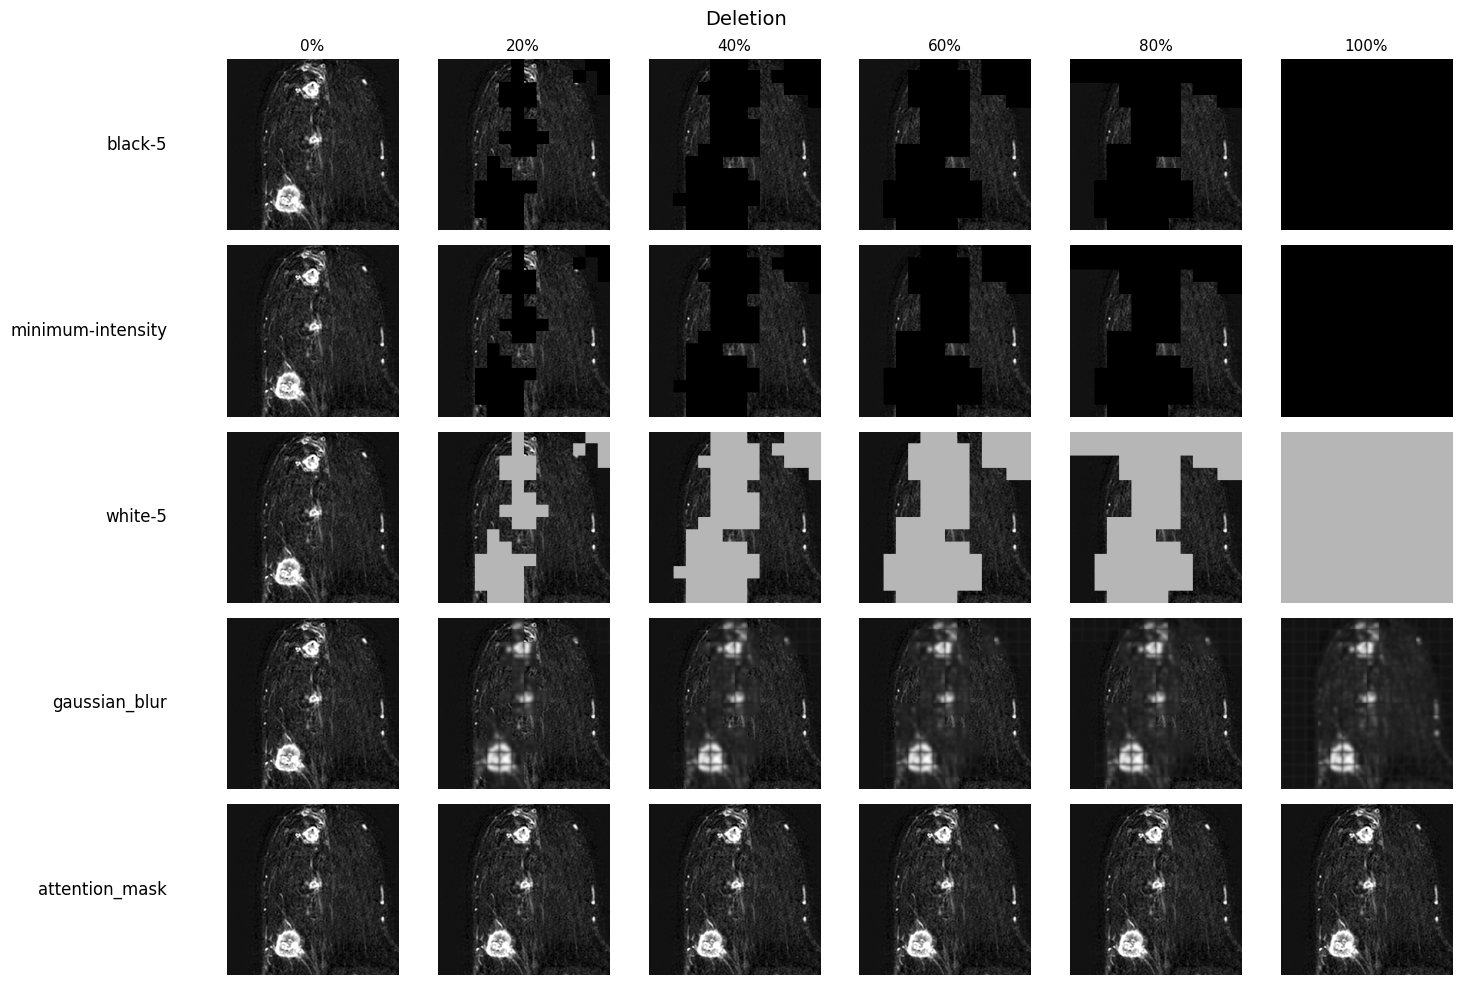

In [16]:
del_results = run_single_mode("deletion")
plot_mode(del_results, "Deletion", batch["source"])

insertion | black-5 | AUC: 0.5671
insertion | minimum-intensity | AUC: 0.9550
insertion | white-5 | AUC: 0.9159
insertion | gaussian_blur | AUC: 0.8279
insertion | attention_mask | AUC: 0.9447


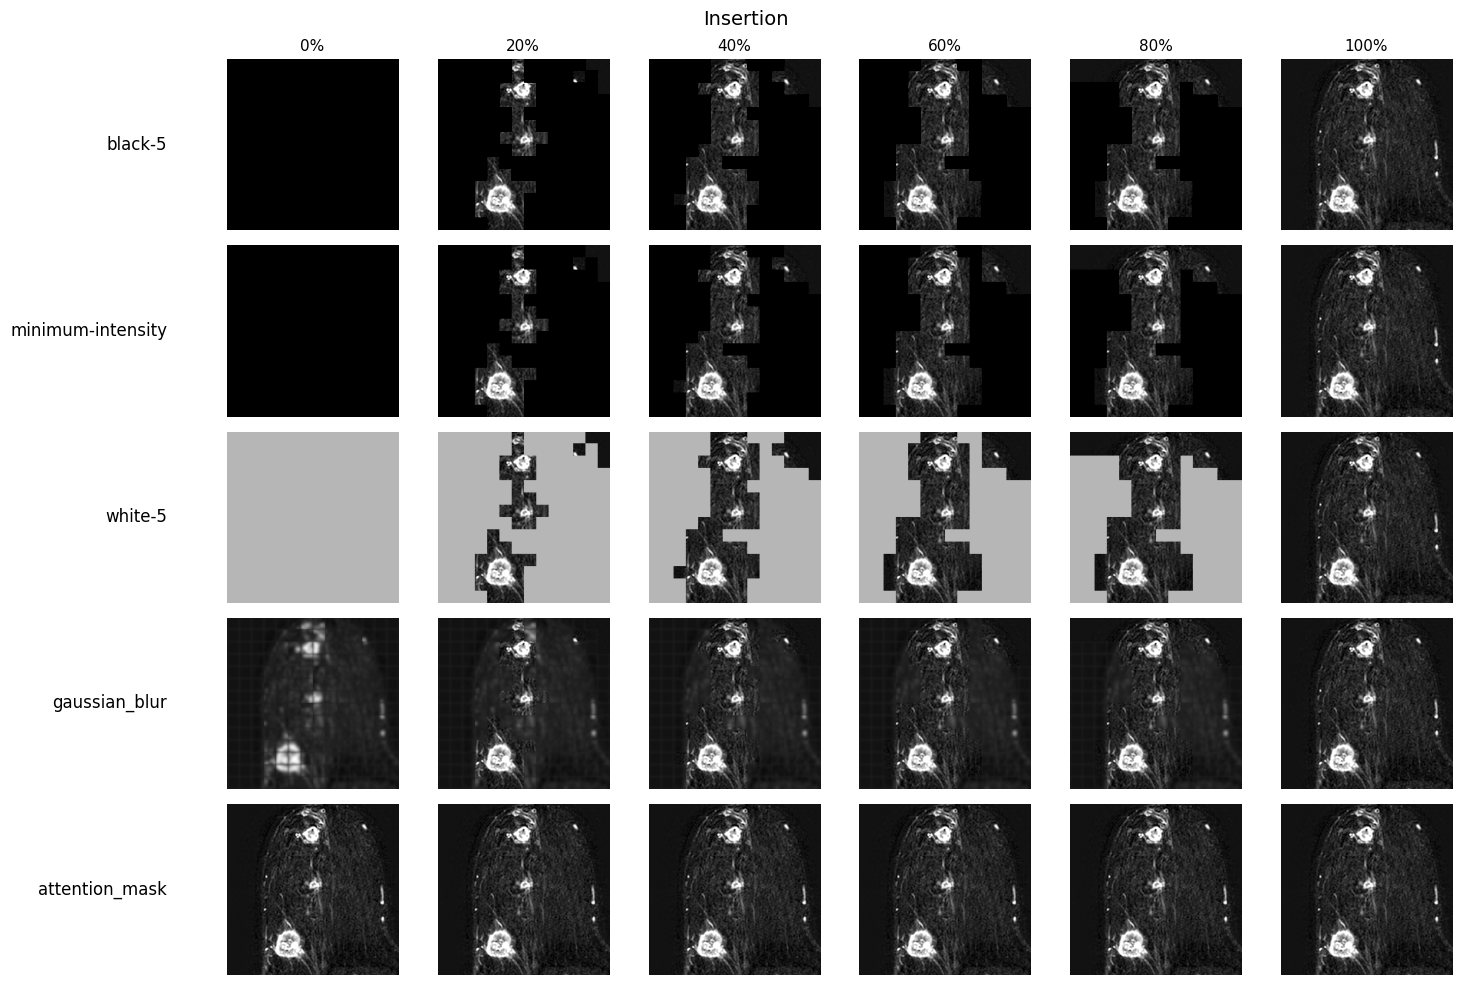

In [18]:
ins_results = run_single_mode("insertion")
plot_mode(ins_results, "Insertion", batch["source"])

negative | black-5 | AUC: 0.6050
negative | minimum-intensity | AUC: 0.9554
negative | white-5 | AUC: 0.9138
negative | gaussian_blur | AUC: 0.8317
negative | attention_mask | AUC: 0.9474


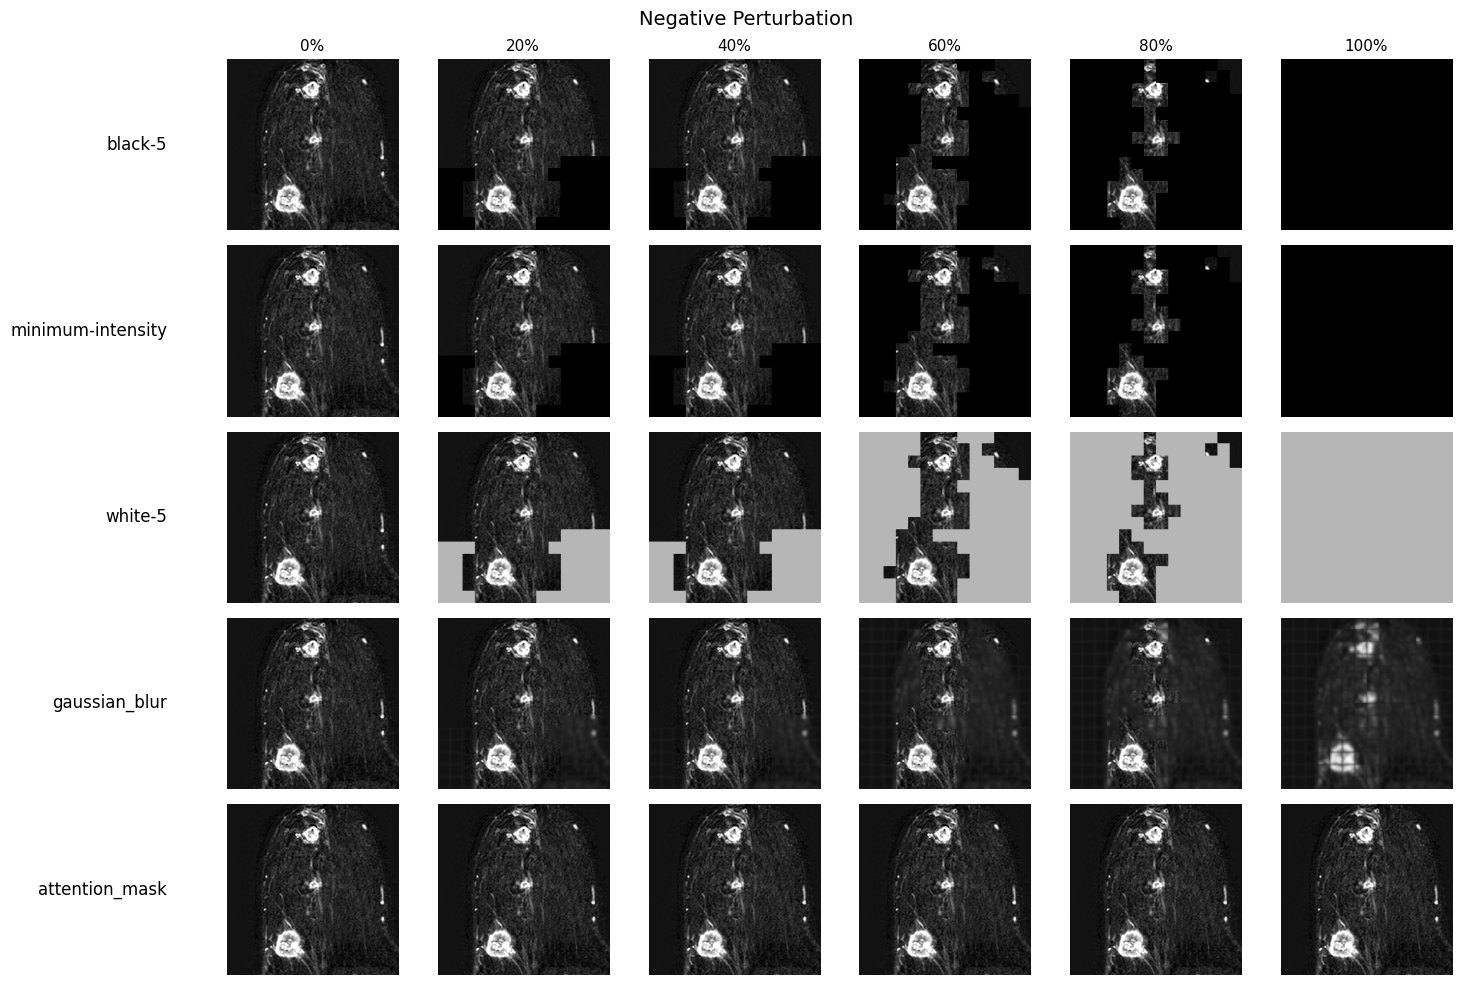

In [19]:
neg_results = run_single_mode("negative")
plot_mode(neg_results, "Negative Perturbation", batch["source"])